In [ ]:
import os


os.environ['USER'] = 'shaans321'
os.environ['REPO'] = 'shaans-ml'
os.environ['TOKEN'] = '****'

# do everything in colab's "root" directory
%cd /content
!git clone https://${TOKEN}@github.com/${USER}/${REPO}.git

# make sure your repo shows up
%ls

/content
Cloning into 'dl-hw'...
remote: Enumerating objects: 51858, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 51858 (delta 8), reused 8 (delta 5), pack-reused 51842 (from 5)
Receiving objects: 100% (51858/51858), 561.36 MiB | 35.65 MiB/s, done.
Resolving deltas: 100% (2595/2595), done.
Updating files: 100% (70258/70258), done.
dl-hw/  sample_data/


In [2]:
%cd /content/{os.environ['REPO']}
%ls

# go to a specific homework
#%mkdir -p aih-hrp/
%cd aih-hrp/
%ls


/content/dl-hw
aih-hrp/  Homework/
/content/dl-hw/aih-hrp
Classifier_Muradataset_20250413_1epoch.th  mura_resnet18_for_ELBOW_DS.pt
Classifier.th                              mura_resnet18_fulldataset25epo.pt
metrics_train.json                         mura_resnet18.pt
model.py                                   train.py
mura_dataset                               utils.py
mura_dataset.py


In [3]:
HOMEWORK_DIR='/content/dl-hw/aih-hrp'

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11")

print("Path to dataset files:", path)
root_path = path

100%|██████████| 3.26G/3.26G [00:28<00:00, 122MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4


In [5]:
# list files from path

import os

# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
if 'path' in locals():
  for filename in os.listdir(path):
    print(f"{path=}")
    print(f"{filename}")

else:
  print("Error: 'path' variable not found. Please run the kagglehub dataset download code first.")


path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_dev.csv
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
phase_1_resnet_mon_jun_26_23-28-30_2023.pt
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA-v1.1
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_train.csv


In [6]:
# list files from path

import os

# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
if 'path' in locals():
  for filename in os.listdir(path):
    print(f"{path=}")
    print(f"{filename}")

else:
  print("Error: 'path' variable not found. Please run the kagglehub dataset download code first.")


path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_dev.csv
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
phase_1_resnet_mon_jun_26_23-28-30_2023.pt
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA-v1.1
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_train.csv


Train DataFrame Head (after re-loading with header inference):
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                path  Split      Bone  \
0  MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...  train  XR_ELBOW   
1  MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...  train  XR_ELBOW   
2  MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...  train  XR_ELBOW   
3  MURA-v1.1\train\XR_ELBOW\patient00016\study1_p...  train  XR_ELBOW   
4  MURA-v1.1\train\XR_ELBOW\patient00016\study1_p...  train  XR_ELBOW   

        Patient       FolderName   Study     Label  
0  patient00011  study1_negative  study1  negative  
1  patient00011  study1_negative  study1  negative  
2  patient00011  study1_negative  study1  negative  
3  patient00016  study1_positive  study1  positive  
4  patient00016  study1_positive  study1  posi

/tmp/ipykernel_3163/1000541807.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mura_df['label'] = mura_df['label'].replace(label_mapping)



DataFrame with extracted info (after re-processing):
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                            filepath  Split      Bone  \
0  MURA-v1.1/train/XR_ELBOW/patient00011/study1_n...  train  XR_ELBOW   
1  MURA-v1.1/train/XR_ELBOW/patient00011/study1_n...  train  XR_ELBOW   
2  MURA-v1.1/train/XR_ELBOW/patient00011/study1_n...  train  XR_ELBOW   
3  MURA-v1.1/train/XR_ELBOW/patient00016/study1_p...  train  XR_ELBOW   
4  MURA-v1.1/train/XR_ELBOW/patient00016/study1_p...  train  XR_ELBOW   

        Patient       FolderName   Study  label body_part study_type  
0  patient00011  study1_negative  study1      0        XR      ELBOW  
1  patient00011  study1_negative  study1      0        XR      ELBOW  
2  patient00011  study1_negative  study1      0        XR      ELBOW  
3  patient00016  study1_positive  st

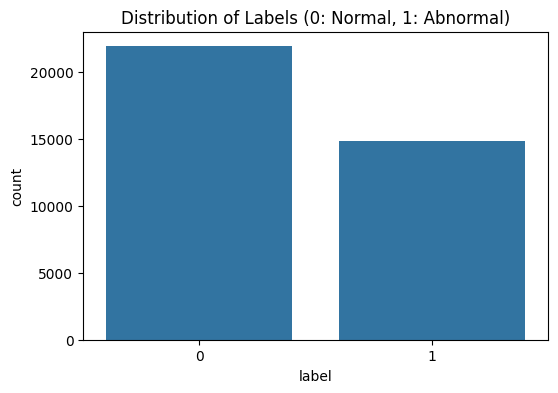

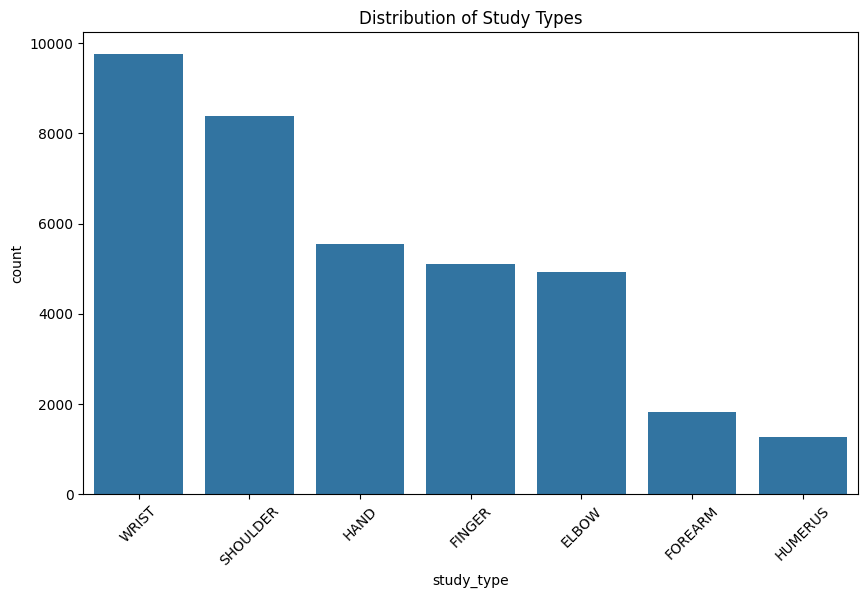

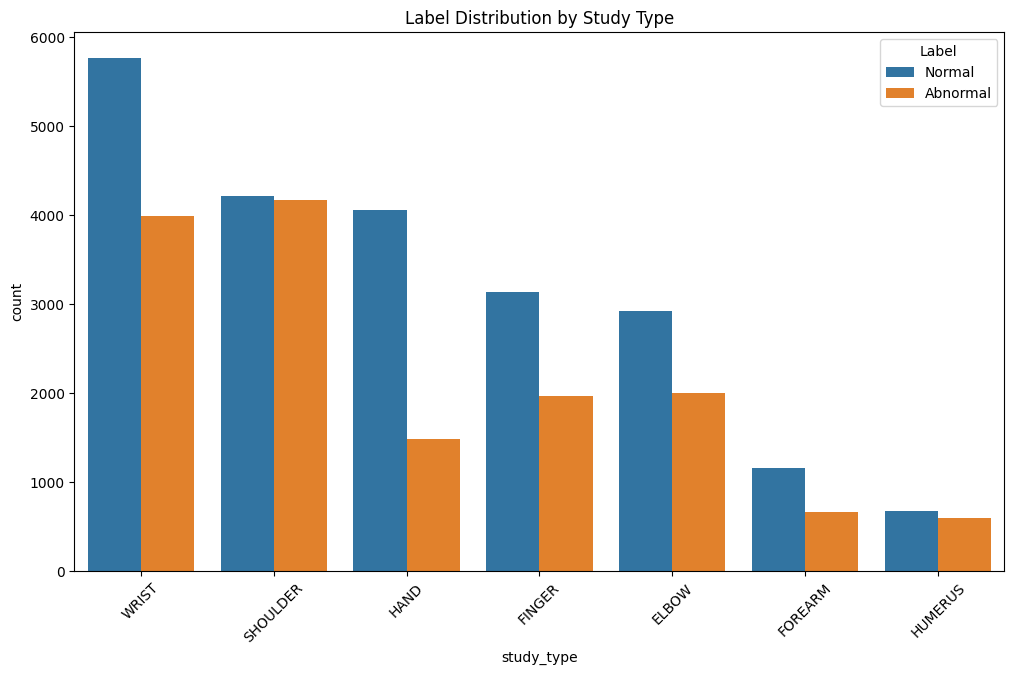


Percentage of Abnormal Cases per Study Type:
label              0         1  abnormal_percentage
study_type                                         
SHOULDER    0.502566  0.497434            49.743406
HUMERUS     0.529088  0.470912            47.091195
WRIST       0.591161  0.408839            40.883921
ELBOW       0.593186  0.406814            40.681403
FINGER      0.614571  0.385429            38.542891
FOREARM     0.637808  0.362192            36.219178
HAND        0.732275  0.267725            26.772506


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the full paths to the CSV files
train_csv_path = os.path.join(path, 'MURA_fn_train.csv')
dev_csv_path = os.path.join(path, 'MURA_fn_dev.csv')

# Load the datasets. Let pandas infer the header (default header=0).
train_df = pd.read_csv(train_csv_path)
dev_df = pd.read_csv(dev_csv_path)

print("Train DataFrame Head (after re-loading with header inference):")
print(train_df.head())
print("\nDev DataFrame Head (after re-loading with header inference):")
print(dev_df.head())

# Rename columns to 'filepath' and 'label' for consistency
# Explicitly rename 'path' to 'filepath' and 'Label' to 'label' as these are the actual column names.
train_df = train_df.rename(columns={'path': 'filepath', 'Label': 'label'})
dev_df = dev_df.rename(columns={'path': 'filepath', 'Label': 'label'})

# Concatenate train and dev data for comprehensive EDA
mura_df = pd.concat([train_df, dev_df], ignore_index=True)

print("\nCombined DataFrame Info (after re-loading):")
mura_df.info()

print("\nCombined DataFrame Description (after re-loading):")
print(mura_df.describe())

print("\nMissing values (after re-loading):")
print(mura_df.isnull().sum())

# Clean the filepath column: replace backslashes with forward slashes for consistent splitting
mura_df['filepath'] = mura_df['filepath'].str.replace('\\', '/', regex=False)

# Convert labels from 'positive'/'negative' to 1/0
label_mapping = {'positive': 1, 'negative': 0}
mura_df['label'] = mura_df['label'].replace(label_mapping)

# Extract body part and study type from filepath
def extract_info(filepath):
    # Example filepath: MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image1.png
    parts = filepath.split('/')
    # Check if parts has enough elements and the expected format to avoid IndexError
    if len(parts) >= 3 and parts[2].startswith('XR_') and '_' in parts[2]:
        body_part_study = parts[2]
        body_part = body_part_study.split('_')[0] # e.g., 'XR_WRIST' -> 'XR'
        study_type = body_part_study.split('_')[1] # e.g., 'XR_WRIST' -> 'WRIST'
    else:
        # Assign default or 'INVALID' values if path format is not as expected
        body_part = 'INVALID_PATH'
        study_type = 'INVALID_PATH'
    return body_part, study_type

mura_df[['body_part', 'study_type']] = mura_df['filepath'].apply(lambda x: pd.Series(extract_info(x)))

# Filter out invalid paths before proceeding with analysis
mura_df = mura_df[mura_df['body_part'] != 'INVALID_PATH']

print("\nDataFrame with extracted info (after re-processing):")
print(mura_df.head())

print("\nDistribution of Labels:")
print(mura_df['label'].value_counts())

print("\nDistribution of Body Parts:")
print(mura_df['body_part'].value_counts())

print("\nDistribution of Study Types:")
print(mura_df['study_type'].value_counts())

# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=mura_df)
plt.title('Distribution of Labels (0: Normal, 1: Abnormal)')
plt.show()

# Visualize body part distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='study_type', data=mura_df, order=mura_df['study_type'].value_counts().index)
plt.title('Distribution of Study Types')
plt.xticks(rotation=45)
plt.show()

# Visualize label distribution by study type
plt.figure(figsize=(12, 7))
sns.countplot(x='study_type', hue='label', data=mura_df, order=mura_df['study_type'].value_counts().index)
plt.title('Label Distribution by Study Type')
plt.xticks(rotation=45)
plt.legend(title='Label', labels=['Normal', 'Abnormal'])
plt.show()

# Calculate and display the percentage of abnormal cases per study type
label_by_study = mura_df.groupby('study_type')['label'].value_counts(normalize=True).unstack().fillna(0)
# Ensure both 0 and 1 columns exist before trying to access them for calculating abnormal percentage
if 1 in label_by_study.columns:
    label_by_study['abnormal_percentage'] = label_by_study[1] * 100 # Assuming 1 is abnormal
else:
    label_by_study['abnormal_percentage'] = 0 # No abnormal cases found for this study type
print("\nPercentage of Abnormal Cases per Study Type:")
print(label_by_study.sort_values(by='abnormal_percentage', ascending=False))

# Further EDA can involve visualizing image examples, but requires loading images.

Data Loading and Merging: We successfully loaded the MURA_fn_train.csv and MURA_fn_dev.csv files and combined them into a single DataFrame named mura_df.
Data Overview: The combined DataFrame contains 36,808 entries with 9 columns, including filepath, label, Split, Bone, Patient, FolderName, Study, body_part, and study_type.
Missing Values: There are no missing values in the dataset, ensuring data completeness for our analysis.
Label Distribution: The dataset has 21,935 normal cases (label 0) and 14,873 abnormal cases (label 1).
Body Part Distribution: All entries are related to 'XR' (X-ray) body parts.
Study Type Distribution: The dataset covers seven study types, with 'WRIST' having the most entries (9,752) and 'HUMERUS' the least (1,272).
Visualizations:
A count plot shows the overall distribution of normal vs. abnormal labels.
Another count plot illustrates the distribution of images across different study types.
A third plot breaks down the label distribution (normal/abnormal) for each study type.
Abnormal Case Percentage by Study Type: The percentage of abnormal cases varies across study types:
SHOULDER: 49.74%
HUMERUS: 47.09%
WRIST: 40.88%
ELBOW: 40.68%
FINGER: 38.54%
FOREARM: 36.22%
HAND: 26.77%

In [14]:
from PIL import Image
import random
import matplotlib.pyplot as plt
import os

# Assuming 'root_path' holds the base path to the downloaded dataset (e.g., /root/.cache/kagglehub/.../versions/4)
# The 'filepath' column in mura_df contains paths like 'MURA-v1.1/train/...'

# Let's first inspect the contents of the root_path to understand the actual directory structure
print(f"Contents of root_path ({root_path}):")
!ls -F {root_path}

# The image paths in mura_df['filepath'] typically start with 'MURA-v1.1/',
# which implies that 'MURA-v1.1' is a top-level directory extracted directly into `root_path`.
# So, simply joining `root_path` with the dataframe's `filepath` should work if 'MURA-v1.1' is a direct subdirectory.
# If the contents of 'MURA-v1.1' were extracted directly into `root_path`, then we need to strip 'MURA-v1.1/'

# For debugging, let's assume the simplest case: filepath is directly relative to root_path.
print(f"Base directory for joining with image paths: {root_path}")

sample_images_info = []
study_types = mura_df['study_type'].unique()

for st in study_types:
    # Get normal cases for the study type
    normal_cases = mura_df[(mura_df['study_type'] == st) & (mura_df['label'] == 0)]
    if not normal_cases.empty:
        sample_images_info.append(normal_cases.sample(1).iloc[0])

    # Get abnormal cases for the study type
    abnormal_cases = mura_df[(mura_df['study_type'] == st) & (mura_df['label'] == 1)]
    if not abnormal_cases.empty:
        sample_images_info.append(abnormal_cases.sample(1).iloc[0])

# Create a figure to display the sample images
plt.figure(figsize=(15, 10))

for i, row_data in enumerate(sample_images_info):
    relative_filepath_from_df = row_data['filepath']

    # Construct the full image path by directly joining root_path and the relative filepath
    # This assumes the 'MURA-v1.1/' prefix in the dataframe's filepath is correct relative to root_path
    full_image_path = os.path.join(root_path, relative_filepath_from_df)

    label_text = 'Abnormal' if row_data['label'] == 1 else 'Normal'
    study_type_text = row_data['study_type']

    print(f"Attempting to open image: {full_image_path}")
    print(f"Does this path exist? {os.path.exists(full_image_path)}")

    try:
        img = Image.open(full_image_path).convert('RGB')
        # Adjust subplot grid dynamically based on the number of images
        plt.subplot(len(sample_images_info) // 2 + 1, 2, i + 1)
        plt.imshow(img)
        plt.title(f"{study_type_text} - {label_text}")
        plt.axis('off')
    except FileNotFoundError:
        print(f"Image not found at expected path: {full_image_path}")
    except Exception as e:
        print(f"Error loading image {full_image_path}: {e}")

plt.tight_layout()
plt.show()

print("\n--- Further Advanced Analysis Ideas ---")
print("1. Image Preprocessing: Apply resizing, normalization, and data augmentation techniques.")
print("2. Custom Dataset Creation: Implement a PyTorch or TensorFlow Dataset class for efficient loading.")
print("3. Model Training: Start building and training a classification model (e.g., ResNet, VGG).")
print("4. Transfer Learning: Utilize pre-trained models for feature extraction or fine-tuning.")
print("5. Performance Evaluation: Implement metrics like accuracy, precision, recall, F1-score, and ROC curves.")
print("6. Grad-CAM Visualization: Understand model predictions by visualizing attention maps on images.")
print("7. Cross-Validation: Implement robust evaluation strategies to ensure model generalization.")

Contents of root_path (/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4):
MURA_fn_dev.csv    MURA-v1.1/
MURA_fn_train.csv  phase_1_resnet_mon_jun_26_23-28-30_2023.pt
Base directory for joining with image paths: /root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4
Attempting to open image: /root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/train/XR_ELBOW/patient06154/study1_negative/image2.png
Does this path exist? False
Image not found at expected path: /root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/train/XR_ELBOW/patient06154/study1_negative/image2.png
Attempting to open image: /root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/train/XR_ELBOW/patient05288/study1_positive/image1.png
Does this path exist? False
Image not found at expected path: /root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/train/XR_ELBOW/pati

<Figure size 1500x1000 with 0 Axes>


--- Further Advanced Analysis Ideas ---
1. Image Preprocessing: Apply resizing, normalization, and data augmentation techniques.
2. Custom Dataset Creation: Implement a PyTorch or TensorFlow Dataset class for efficient loading.
3. Model Training: Start building and training a classification model (e.g., ResNet, VGG).
4. Transfer Learning: Utilize pre-trained models for feature extraction or fine-tuning.
5. Performance Evaluation: Implement metrics like accuracy, precision, recall, F1-score, and ROC curves.
6. Grad-CAM Visualization: Understand model predictions by visualizing attention maps on images.
7. Cross-Validation: Implement robust evaluation strategies to ensure model generalization.


### Feature Engineering: Patient-Level Statistics

We will now aggregate information at the patient level to create new features. This can reveal insights into individual patient study patterns and the prevalence of abnormality among them.

In [15]:
# Calculate the number of studies per patient
patient_studies_count = mura_df.groupby('Patient')['Study'].nunique().reset_index()
patient_studies_count.rename(columns={'Study': 'num_studies'}, inplace=True)

# Calculate the number of abnormal studies per patient
abnormal_patient_studies = mura_df[mura_df['label'] == 1]
patient_abnormal_studies_count = abnormal_patient_studies.groupby('Patient')['Study'].nunique().reset_index()
patient_abnormal_studies_count.rename(columns={'Study': 'num_abnormal_studies'}, inplace=True)

# Merge these new features back into a patient-level DataFrame
patient_features = pd.merge(patient_studies_count, patient_abnormal_studies_count, on='Patient', how='left')
patient_features['num_abnormal_studies'] = patient_features['num_abnormal_studies'].fillna(0).astype(int)

# Calculate abnormality rate per patient
patient_features['abnormality_rate'] = patient_features['num_abnormal_studies'] / patient_features['num_studies']

# Display the new patient-level features
print("\nPatient-level features:")
display(patient_features.head())

# Optionally, merge these features back into the original mura_df if needed
# mura_df = pd.merge(mura_df, patient_features, on='Patient', how='left')


Patient-level features:


,Patient,num_studies,num_abnormal_studies,abnormality_rate
0,patient00001,1,1,1.0
1,patient00002,1,1,1.0
2,patient00003,1,1,1.0
3,patient00004,1,1,1.0
4,patient00005,1,1,1.0


These patient-level features (`num_studies`, `num_abnormal_studies`, `abnormality_rate`) can now be used for further analysis, such as identifying patients with a high incidence of abnormal findings or understanding patient behavior within the dataset.

/tmp/ipykernel_3163/143179878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_by_study.index, y='abnormal_percentage', data=label_by_study.reset_index(), palette='viridis')


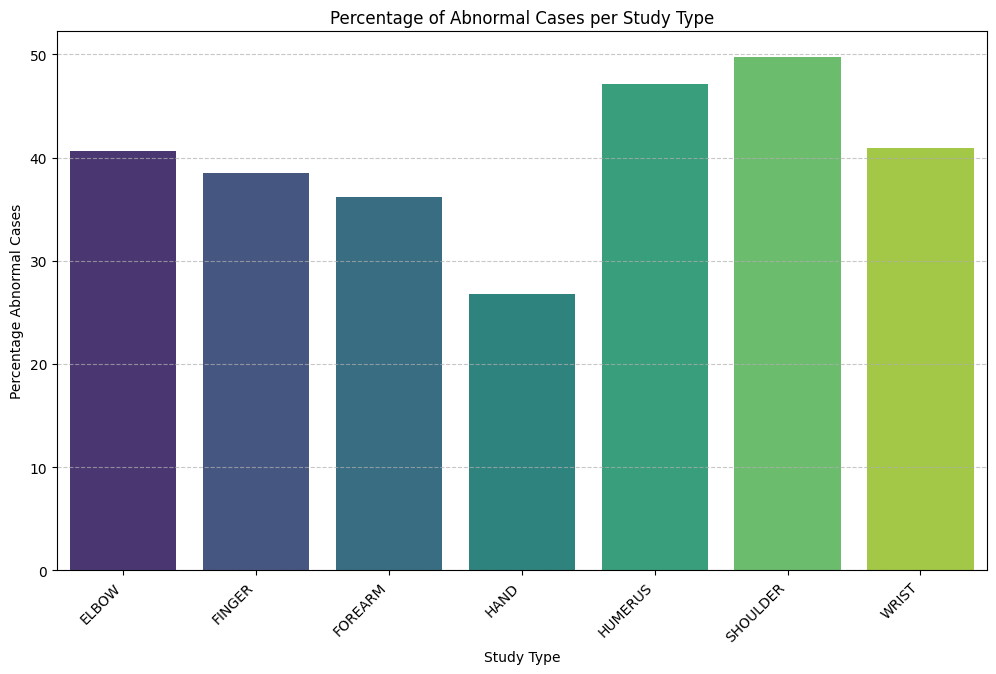

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=label_by_study.index, y='abnormal_percentage', data=label_by_study.reset_index(), palette='viridis')
plt.title('Percentage of Abnormal Cases per Study Type')
plt.xlabel('Study Type')
plt.ylabel('Percentage Abnormal Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

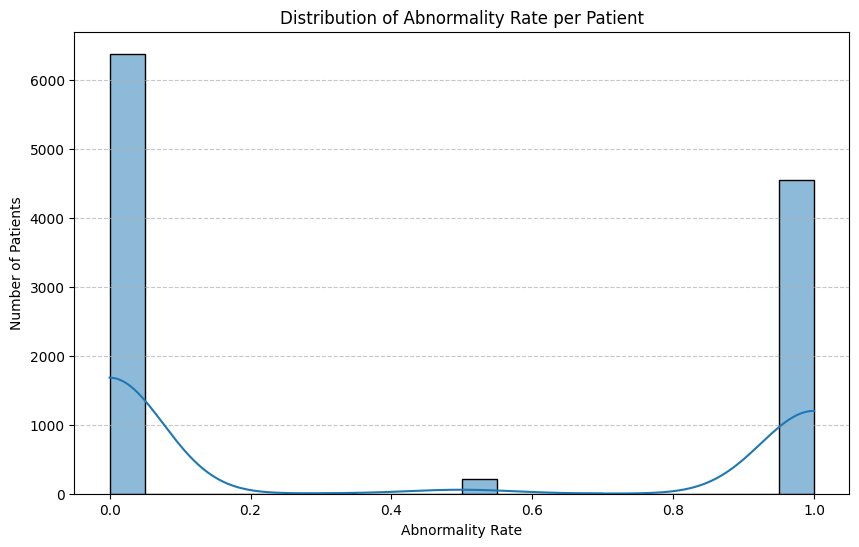

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(patient_features['abnormality_rate'], bins=20, kde=True)
plt.title('Distribution of Abnormality Rate per Patient')
plt.xlabel('Abnormality Rate')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [1]:
display(label_by_study)

NameError: name 'label_by_study' is not defined